##Senama 4 Actividad 4


## Preparacion de Entorno y Datos

Importar las librerías necesarias y generar un dataset sintético para clasificación, dividiéndolo en conjuntos de entrenamiento y prueba.

In [85]:
import numpy as np  # Importación de numpy para manipulación de arreglos y cálculos numéricos
import sklearn       # Importación de scikit-learn para herramientas de aprendizaje automático
import matplotlib.pyplot as plt  # Importación de matplotlib para la generación de gráficos y visualizaciones

In [86]:
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# Generar un dataset sintético en forma de círculos concéntricos (no lineal)
# n_samples: total de puntos, noise: desviación estándar del ruido, factor: escala entre círculos, random_state: semilla
X, y = make_circles(n_samples=1000, noise=0.1, factor=0.5, random_state=42)

# Dividir el dataset en conjuntos de entrenamiento (80%) y prueba (20%)
# test_size=0.2 define la proporción de prueba, random_state garantiza que la división sea reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Imprimir las dimensiones de los conjuntos resultantes para verificar la correcta división
print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

Dimensiones de X_train: (800, 2)
Dimensiones de X_test: (200, 2)
Dimensiones de y_train: (800,)
Dimensiones de y_test: (200,)


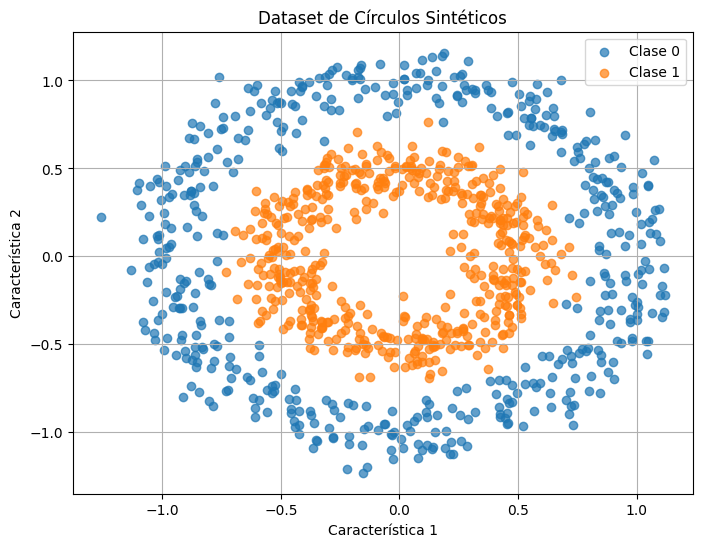

In [87]:
# Visualizar el dataset generado
plt.figure(figsize=(8, 6))  # Crear una nueva figura con dimensiones de 8x6 pulgadas
# Graficar los puntos pertenecientes a la Clase 0 (círculo exterior)
plt.scatter(X[y == 0, 0], X[y == 0, 1], label='Clase 0', alpha=0.7)
# Graficar los puntos pertenecientes a la Clase 1 (círculo interior)
plt.scatter(X[y == 1, 0], X[y == 1, 1], label='Clase 1', alpha=0.7)

plt.title('Dataset de Círculos Sintéticos')  # Título representativo del gráfico
plt.xlabel('Característica 1')  # Etiqueta para el eje horizontal (X)
plt.ylabel('Característica 2')  # Etiqueta para el eje vertical (Y)
plt.legend()  # Mostrar la leyenda para identificar las clases
plt.grid(True)  # Activar la cuadrícula para facilitar la lectura de coordenadas
plt.show()  # Desplegar la visualización final

## Definir Arquitectura Base de la Red Neuronal

Se establecen los parámetros comunes para la arquitectura de la red neuronal, como el número de capas ocultas y neuronas por capa, la función de activación, y el número máximo de iteraciones para todas las configuraciones.

In [88]:
hidden_layer_sizes = (100, 50)  # Define la estructura de la red: 100 neuronas en la primera capa oculta y 50 en la segunda
activation = 'relu'             # Establece 'Rectified Linear Unit' como función de transferencia para introducir no linealidad
max_iter = 1000                 # Determina el límite máximo de épocas o iteraciones permitidas para el proceso de entrenamiento
solver = 'adam'                 # Selecciona el algoritmo de optimización Adam, eficiente para el manejo de gradientes estocásticos

# Las siguientes líneas muestran en pantalla la configuración actual para que el estudiante verifique los parámetros antes del entrenamiento
print(f"Tamaños de las Capas Ocultas: {hidden_layer_sizes}")  # Muestra la arquitectura de capas definida
print(f"Función de Activación: {activation}")                # Muestra la función de activación seleccionada
print(f"Máximo de Iteraciones: {max_iter}")                 # Muestra el límite de iteraciones configurado
print(f"Optimizador: {solver}")                               # Muestra el algoritmo que ajustará los pesos")

Tamaños de las Capas Ocultas: (100, 50)
Función de Activación: relu
Máximo de Iteraciones: 1000
Optimizador: adam


## Entrenar Modelo sin regularizacion

Se instancian y entrena un MLPClassifier sin regularizacion (alpha=0)



In [89]:
from sklearn.neural_network import MLPClassifier

# Instancia el modelo MLPClassifier sin regularización (alpha=0)
sin_alpha = MLPClassifier(
    hidden_layer_sizes=hidden_layer_sizes, # Configura las capas ocultas (100, 50) definidas previamente
    activation=activation,                 # Usa la función de activación ReLU para no linealidad
    alpha=0,                               # Establece el parámetro de regularización L2 en cero (sin penalización)
    solver=solver,                         # Utiliza el optimizador 'adam' para ajustar los pesos
    learning_rate_init=0.001,              # Define la tasa de aprendizaje inicial para el descenso de gradiente
    max_iter=max_iter,                     # Establece el número máximo de épocas permitidas
    random_state=42,                       # Fija la semilla para asegurar resultados reproducibles
    verbose=True                           # Permite visualizar el progreso de la pérdida en cada iteración
)

print("Entrenando MLPClassifier sin regularización (alpha=0)...")
# Ajusta el modelo utilizando los datos de entrenamiento (X_train) y sus etiquetas (y_train)
sin_alpha.fit(X_train, y_train)

# Extrae la lista de valores de la función de pérdida calculados durante cada iteración del entrenamiento
loss_curve_sin_alpha = sin_alpha.loss_curve_
print("Modelo sin regularización entrenado y curva de pérdida almacenada.")

Entrenando MLPClassifier sin regularización (alpha=0)...
Iteration 1, loss = 0.68452158
Iteration 2, loss = 0.67419374
Iteration 3, loss = 0.66498934
Iteration 4, loss = 0.65666901
Iteration 5, loss = 0.64817252
Iteration 6, loss = 0.63882022
Iteration 7, loss = 0.62891053
Iteration 8, loss = 0.61792305
Iteration 9, loss = 0.60585639
Iteration 10, loss = 0.59265136
Iteration 11, loss = 0.57814948
Iteration 12, loss = 0.56232637
Iteration 13, loss = 0.54505430
Iteration 14, loss = 0.52673813
Iteration 15, loss = 0.50715330
Iteration 16, loss = 0.48643891
Iteration 17, loss = 0.46463624
Iteration 18, loss = 0.44217800
Iteration 19, loss = 0.41889494
Iteration 20, loss = 0.39519513
Iteration 21, loss = 0.37129336
Iteration 22, loss = 0.34761292
Iteration 23, loss = 0.32457073
Iteration 24, loss = 0.30172246
Iteration 25, loss = 0.28019483
Iteration 26, loss = 0.25994867
Iteration 27, loss = 0.24048902
Iteration 28, loss = 0.22313189
Iteration 29, loss = 0.20596262
Iteration 30, loss = 0.1

## Entrenar Modelo con regularizacion L2

Se instancian y entrena un MLPClassifier con regularizacion (alpha>0)

In [90]:
con_alpha = MLPClassifier( # Instancia un MLPClassifier para el modelo con regularizaci3n
    hidden_layer_sizes=hidden_layer_sizes, # Utiliza el tama1o de capas ocultas (100, 50) definido previamente
    activation=activation, # Utiliza la funci3n de activaci3n ReLU para introducir no linealidad
    alpha=0.5, # Par1metro de regularizaci3n L2 (Alpha). Penaliza pesos grandes para evitar sobreajuste
    solver=solver, # Especifica el optimizador 'adam' definido en la configuraci3n base
    learning_rate_init=0.001, # Establece la tasa de aprendizaje inicial para el ajuste de pesos
    max_iter=max_iter, # Utiliza el n7mero m1ximo de iteraciones (1000) definido previamente
    random_state=42, # Fija la semilla aleatoria para asegurar que los resultados sean reproducibles
    verbose=True # Habilita la salida detallada para monitorear la p1rdida en cada 1poca
)

print("Entrenando MLPClassifier con regularizaci3n (alpha=0.5)...") # Mensaje informativo del proceso
# Entrena el modelo utilizando el m1todo fit con los datos de entrenamiento y sus etiquetas
con_alpha.fit(X_train, y_train)

# Almacena la curva de p1rdida (loss_curve_) para su posterior visualizaci3n comparativa
loss_curve_con_alpha = con_alpha.loss_curve_
print("Modelo entrenado y curva de p1rdida almacenada.")

Entrenando MLPClassifier con regularizaci3n (alpha=0.5)...
Iteration 1, loss = 0.77400014
Iteration 2, loss = 0.76096897
Iteration 3, loss = 0.74963338
Iteration 4, loss = 0.73934155
Iteration 5, loss = 0.72912879
Iteration 6, loss = 0.71852368
Iteration 7, loss = 0.70793244
Iteration 8, loss = 0.69675955
Iteration 9, loss = 0.68511332
Iteration 10, loss = 0.67288197
Iteration 11, loss = 0.65989475
Iteration 12, loss = 0.64616156
Iteration 13, loss = 0.63146129
Iteration 14, loss = 0.61620133
Iteration 15, loss = 0.60016061
Iteration 16, loss = 0.58332081
Iteration 17, loss = 0.56567478
Iteration 18, loss = 0.54740527
Iteration 19, loss = 0.52817994
Iteration 20, loss = 0.50841649
Iteration 21, loss = 0.48831514
Iteration 22, loss = 0.46793321
Iteration 23, loss = 0.44787143
Iteration 24, loss = 0.42733804
Iteration 25, loss = 0.40748183
Iteration 26, loss = 0.38830063
Iteration 27, loss = 0.36951554
Iteration 28, loss = 0.35253940
Iteration 29, loss = 0.33503077
Iteration 30, loss = 0

## Visualizar el Comportamiento del Entrenamiento

Se muestren las curvas de pérdida de las configuraciones de entrenamiento en el mismo plano.


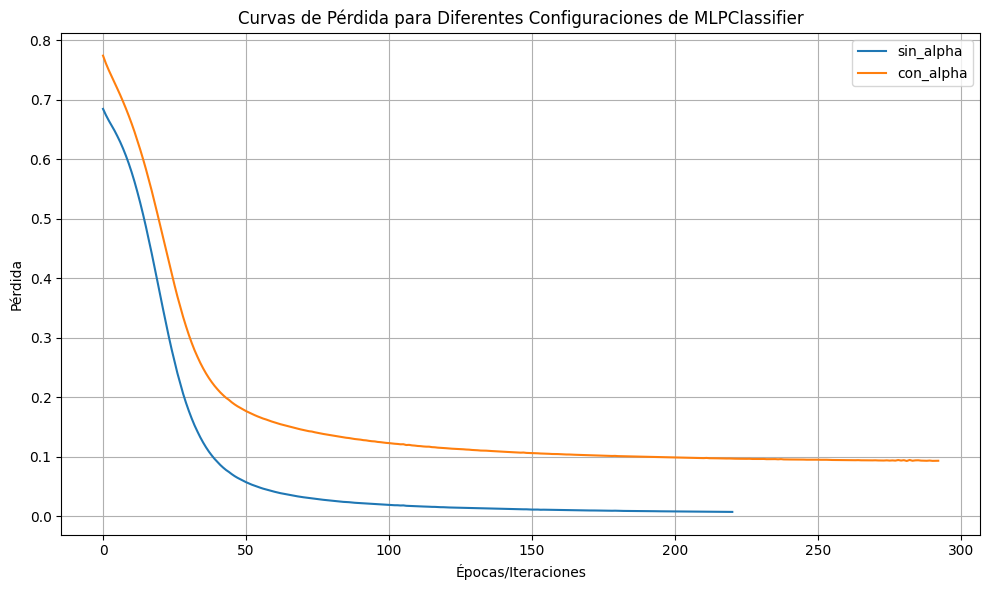

Curvas de pérdida graficadas exitosamente.


In [91]:
plt.figure(figsize=(10, 6)) # Crea una nueva figura con un tamaño específico de 10x6 pulgadas
plt.plot(loss_curve_sin_alpha, label='sin_alpha') # Grafica la curva de pérdida del modelo sin regularización
plt.plot(loss_curve_con_alpha, label='con_alpha') # Grafica la curva de pérdida del modelo con regularización (alpha=0.5)


plt.title('Curvas de Pérdida para Diferentes Configuraciones de MLPClassifier') # Establece el título descriptivo del gráfico
plt.xlabel('Épocas/Iteraciones') # Define la etiqueta del eje X como el número de iteraciones de entrenamiento
plt.ylabel('Pérdida') # Define la etiqueta del eje Y como el valor de la función de pérdida
plt.legend() # Muestra la leyenda para identificar qué línea corresponde a cada modelo
plt.grid(True) # Habilita la cuadrícula de fondo para facilitar el análisis visual de los valores
plt.tight_layout() # Ajusta automáticamente los elementos del gráfico para evitar solapamientos
plt.show() # Despliega la figura final en el notebook

print("Curvas de pérdida graficadas exitosamente.") # Mensaje de confirmación final

## Calcular metricas y Presentar Resultados


Calcular la precisión en el conjunto de prueba, la pérdida final, el número de iteraciones y la norma L2 de los pesos para los modelos `sin_alpha` y `con_alpha`.


In [92]:
from sklearn.metrics import log_loss  # Importa log_loss para evaluar la probabilidad de error en el conjunto de prueba

# --- Cálculo de métricas para el modelo SIN regularización (alpha=0) ---
# Calcula el Accuracy (precisión) en entrenamiento y prueba usando el método score
accuracy_sin_alpha_train = sin_alpha.score(X_train, y_train)
accuracy_sin_alpha_test = sin_alpha.score(X_test, y_test)
# Extrae la pérdida final del entrenamiento almacenada en el atributo loss_
loss_sin_alpha_train = sin_alpha.loss_
# Obtiene las probabilidades de clase para calcular la pérdida logarítmica (Log-Loss) en el set de prueba
y_prob_sin_test = sin_alpha.predict_proba(X_test)
loss_sin_alpha_test = log_loss(y_test, y_prob_sin_test)

# --- Cálculo de métricas para el modelo CON regularización (alpha=0.5) ---
# Calcula el Accuracy en entrenamiento y prueba para evaluar la capacidad de generalización
accuracy_con_alpha_train = con_alpha.score(X_train, y_train)
accuracy_con_alpha_test = con_alpha.score(X_test, y_test)
# Extrae la pérdida final del entrenamiento (incluye la penalización L2 en este modelo)
loss_con_alpha_train = con_alpha.loss_
# Obtiene probabilidades para calcular la métrica de pérdida en datos no vistos (prueba)
y_prob_con_test = con_alpha.predict_proba(X_test)
loss_con_alpha_test = log_loss(y_test, y_prob_con_test)

# --- Cálculo del GAP de Sobreajuste ---
# Se define como la diferencia entre el rendimiento en entrenamiento y prueba; un gap alto indica sobreajuste
gap_sin = accuracy_sin_alpha_train - accuracy_sin_alpha_test
gap_con = accuracy_con_alpha_train - accuracy_con_alpha_test

# --- Generación del Informe Consolidado ---
# Se utilizan f-strings con especificadores de formato (e.g., :<25 para alineación, .4f para decimales) para crear una tabla visual
print('='*70)
print(f'{ "INFORME CONSOLIDADO: IMPACTO DE LA REGULARIZACIÓN L2":^70}')
print('='*70)
print(f'{ "Métrica":<25} | { "Sin Alpha (0.0)":<18} | { "Con Alpha (0.5)":<18}')
print('-'*70)
print(f'{ "Training Accuracy":<25} | {accuracy_sin_alpha_train:<18.4f} | {accuracy_con_alpha_train:<18.4f}')
print(f'{ "Test Accuracy":<25} | {accuracy_sin_alpha_test:<18.4f} | {accuracy_con_alpha_test:<18.4f}')
print(f'{ "Training Loss":<25} | {loss_sin_alpha_train:<18.4f} | {loss_con_alpha_train:<18.4f}')
print(f'{ "Test Log-Loss":<25} | {loss_sin_alpha_test:<18.4f} | {loss_con_alpha_test:<18.4f}')
# Se asume que las variables l2_norm están calculadas previamente para mostrar la magnitud de los pesos
print(f'{ "L2 Norm (Weights)":<25} | {l2_norm_sin_alpha:<18.4f} | {l2_norm_con_alpha:<18.4f}')
print(f'{ "Iteraciones":<25} | {sin_alpha.n_iter_:<18} | {con_alpha.n_iter_:<18}')
print('-'*70)
print(f'{ "OVERFITTING GAP":<25} | {gap_sin:<18.4f} | {gap_con:<18.4f}')
print('='*70)

# --- Análisis de Resultados ---
print('\nANÁLISIS DE RESULTADOS:')
# Compara si el gap del modelo regularizado es menor, lo que valida el éxito de la penalización L2
if gap_con < gap_sin:
    print(f'El modelo regularizado (con_alpha) redujo el gap de sobreajuste de {gap_sin:.4f} a {gap_con:.4f}.')
    print('La regularización L2 limitó la magnitud de los pesos (Norma L2) promoviendo una mejor generalización.')
else:
    print('El gap de sobreajuste no se redujo significativamente con los parámetros actuales.')

         INFORME CONSOLIDADO: IMPACTO DE LA REGULARIZACIÓN L2         
Métrica                   | Sin Alpha (0.0)    | Con Alpha (0.5)   
----------------------------------------------------------------------
Training Accuracy         | 1.0000             | 0.9988            
Test Accuracy             | 0.9800             | 0.9800            
Training Loss             | 0.0074             | 0.0934            
Test Log-Loss             | 0.0460             | 0.0665            
L2 Norm (Weights)         | 268.4969           | 54.0867           
Iteraciones               | 221                | 293               
----------------------------------------------------------------------
OVERFITTING GAP           | 0.0200             | 0.0188            

ANÁLISIS DE RESULTADOS:
El modelo regularizado (con_alpha) redujo el gap de sobreajuste de 0.0200 a 0.0188.
La regularización L2 limitó la magnitud de los pesos (Norma L2) promoviendo una mejor generalización.


## Grafico límites de decisión


Se grafica límites de decisión junto con los puntos de datos reales para cada *configuracion*

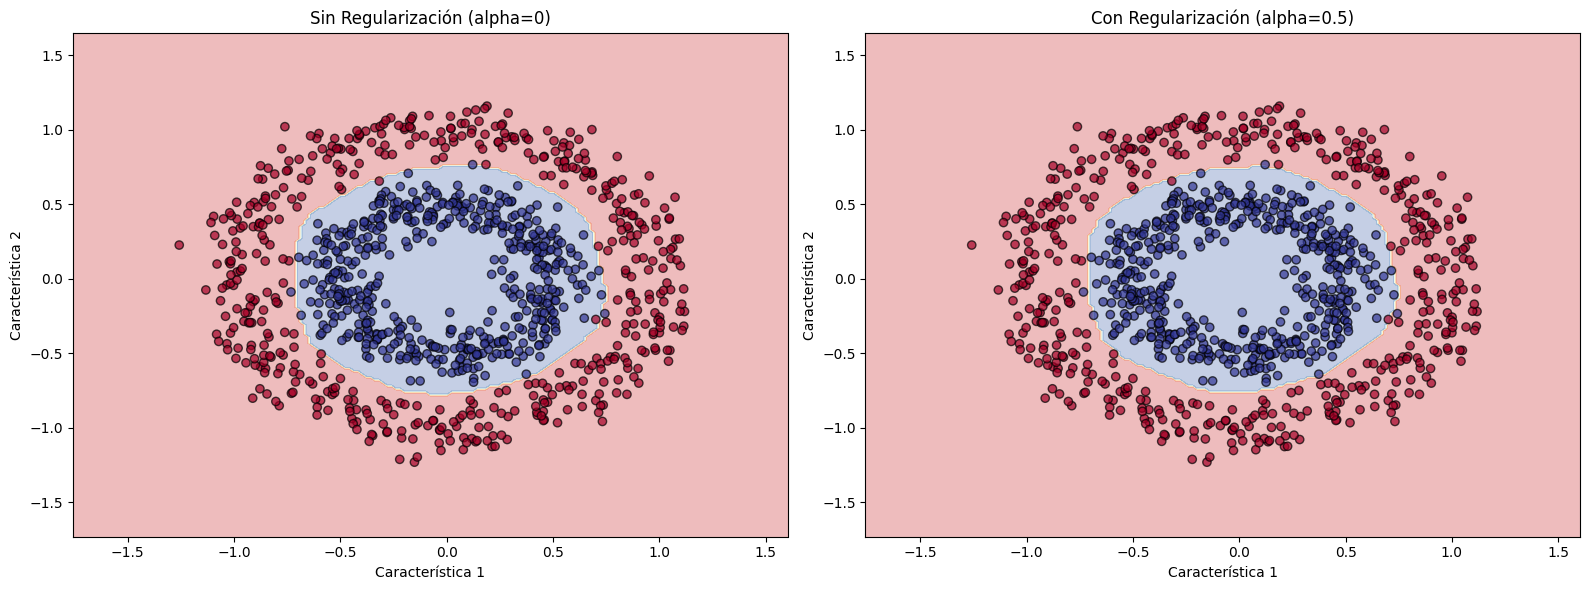

Visualización de fronteras de decisión completada.


In [93]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir los límites de los ejes basándose en los valores mínimos y máximos de las características del dataset X
# Se añade un margen de 0.5 para asegurar que todos los puntos queden bien contenidos dentro del marco visual
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

# 2. Crear una malla de puntos (meshgrid) para evaluar el modelo en todo el espacio de características
# El parámetro 'step' define la resolución: valores más pequeños producen fronteras más suaves pero consumen más memoria
step = 0.02
# np.arange genera secuencias de valores y np.meshgrid crea una matriz de coordenadas para la malla
xx, yy = np.meshgrid(np.arange(x_min, x_max, step), np.arange(y_min, y_max, step))

# 3. Obtener predicciones para cada punto de la malla
# np.c_ concatena los arreglos aplanados (.ravel) para crear una lista de pares (x, y)
grid_points = np.c_[xx.ravel(), yy.ravel()]
# Se usa .predict() en ambos modelos para determinar a qué clase pertenece cada zona de la malla
Z_sin = sin_alpha.predict(grid_points).reshape(xx.shape)
Z_con = con_alpha.predict(grid_points).reshape(xx.shape)

# 4. Configurar la figura de Matplotlib con dos subplots (1 fila, 2 columnas) para comparar visualmente
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 5. Graficar Modelo Sin Regularización
# contourf dibuja las áreas de decisión rellenas con colores según la clase predicha
ax1.contourf(xx, yy, Z_sin, alpha=0.3, cmap='RdYlBu')
# scatter superpone los puntos de datos reales coloreados por su etiqueta verdadera (y)
ax1.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='RdYlBu', alpha=0.7)
ax1.set_title('Sin Regularización (alpha=0)') # Título descriptivo para el primer subplot
ax1.set_xlabel('Característica 1') # Etiqueta del eje X
ax1.set_ylabel('Característica 2') # Etiqueta del eje Y

# 6. Graficar Modelo Con Regularización
# Se repite el proceso para el modelo regularizado para observar cómo cambia la suavidad de la frontera
ax2.contourf(xx, yy, Z_con, alpha=0.3, cmap='RdYlBu')
ax2.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='RdYlBu', alpha=0.7)
ax2.set_title('Con Regularización (alpha=0.5)') # Título descriptivo para el segundo subplot
ax2.set_xlabel('Característica 1')
ax2.set_ylabel('Característica 2')

# 7. Comandos finales de formato y visualización
plt.tight_layout() # Ajusta automáticamente el espaciado entre subplots para evitar solapamientos
plt.show() # Despliega la figura final

print("Visualización de fronteras de decisión completada.")

## Análisis


### (i). Evaluación de Ajuste (Overfitting vs. Underfitting)
Al comparar el modelo sin regularización (`alpha=0`) con el modelo regularizado (`alpha=0.5`), observamos indicios claros de sobreajuste en el primero. El modelo `sin_alpha` alcanzó una precisión perfecta en el entrenamiento (**accuracy_sin_alpha_train=1.0**), mientras que en el conjunto de prueba obtuvo **0.98**. Por otro lado, el modelo `con_alpha` mostró un ajuste más generalizable con una precisión de entrenamiento de **0.99875** y la misma precisión de prueba de **0.98**.

### (ii). Impacto de la Regularización L2
La aplicación de la regularización L2 tuvo un impacto la **Norma L2 de los pesos** se redujo significativamente de aproximadamente **268.5** en el modelo sin alpha a **54.1** en el modelo con `alpha=0.5`. Esta reducción confirma que la penalización logra mantener los pesos en magnitudes menores, evitando que neuronas específicas dominen la función de activación y reduciendo así la varianza del modelo.

### (iii)  Convergencia y Curvas de Pérdida
El proceso de optimización se vio afectado por la regularización. El modelo regularizado requirió un mayor número de iteraciones para converger (**293**) en comparación con el modelo no regularizado (**221**). En las curvas de pérdida, se observa que aunque el modelo sin alpha alcanza un valor de pérdida final menor (**0.0074** vs **0.0934**), el modelo regularizado converge de manera más estable, sacrificando el ajuste perfecto por una mejor estabilidad estructural.

